# Pothole Detection using Smartphone Sensor Data

Extended notebook with preprocessing, machine learning pipeline, cross-validation, signal visualisation, and GPS mapping.

In [ ]:
# =========================================
# 1. Setup & Imports
# =========================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import joblib

# Optional: for GPS visualisation
import folium

# Set visualisation style
sns.set(style="whitegrid")

print("✅ Libraries loaded")


✅ Libraries loaded


In [ ]:
!fusermount -u /content/drive
!rm -rf /content/drive


fusermount: failed to unmount /content/drive: Invalid argument


In [ ]:
# =========================================
# 2. Mount Google Drive, Convert .mat → CSV, and Load Dataset
# =========================================
from google.colab import drive
import scipy.io


drive.mount('/content/drive', force_remount=True)



# Define folders
mat_folder = "/content/drive/MyDrive/datasets/preprocessed_mat"
csv_output_folder = "/content/drive/MyDrive/datasets/converted_csv"
os.makedirs(csv_output_folder, exist_ok=True)

def convert_mat_to_csv(mat_file, output_folder):
    """Convert a single .mat file into CSV format."""
    mat = scipy.io.loadmat(mat_file)

    # Inspect keys
    print(f"Processing {os.path.basename(mat_file)}, keys: {list(mat.keys())}")

    try:
        df = pd.DataFrame({
            "acc_x": mat["xlacc"].flatten(),
            "acc_y": mat["ylacc"].flatten(),
            "acc_z": mat["zlacc"].flatten(),
            "gyro_x": mat["xgyro"].flatten() if "xgyro" in mat else 0,
            "gyro_y": mat["ygyro"].flatten() if "ygyro" in mat else 0,
            "gyro_z": mat["zgyro"].flatten() if "zgyro" in mat else 0,
            "label": mat["label"].flatten() if "label" in mat else "unknown"
        })
    except KeyError as e:
        print(f"⚠ Missing key in {mat_file}: {e}")
        return None

    # Save CSV
    base_name = os.path.basename(mat_file).replace(".mat", ".csv")
    csv_path = os.path.join(output_folder, base_name)
    df.to_csv(csv_path, index=False)
    print(f"✅ Saved {csv_path}, shape {df.shape}")
    return df

# Convert all .mat files if not already converted
all_mats = glob.glob(os.path.join(mat_folder, "*.mat"))
print(f"Found {len(all_mats)} .mat files in {mat_folder}")

df_list = []
for f in all_mats:
    try:
        df = convert_mat_to_csv(f, csv_output_folder)
        if df is not None and df.shape[0] > 0:
            df_list.append(df)
    except Exception as e:
        print(f"❌ Error converting {f}: {e}")

if len(df_list) == 0:
    raise ValueError("No valid data could be loaded from .mat files!")

# Merge into single DataFrame
data = pd.concat(df_list, ignore_index=True)

print("\n✅ Data loaded successfully")
print("Data preview:")
display(data.head())

print("\nColumns:", list(data.columns))
if 'label' in data.columns:
    print("\nClass distribution:")
    print(data['label'].value_counts())


Mounted at /content/drive
Found 920 .mat files in /content/drive/MyDrive/datasets/preprocessed_mat
Processing Aligator cracking8_22-Feb-2021.mat, keys: ['__header__', '__version__', '__globals__', 'label', 'xlacc', 'ylacc', 'zlacc']
✅ Saved /content/drive/MyDrive/datasets/converted_csv/Aligator cracking8_22-Feb-2021.csv, shape (218, 7)
Processing Bump2_15-Feb-2021.mat, keys: ['__header__', '__version__', '__globals__', 'label', 'xlacc', 'ylacc', 'zlacc']
✅ Saved /content/drive/MyDrive/datasets/converted_csv/Bump2_15-Feb-2021.csv, shape (179, 7)
Processing Aligator cracking48_15-Feb-2021.mat, keys: ['__header__', '__version__', '__globals__', 'label', 'xlacc', 'ylacc', 'zlacc']
✅ Saved /content/drive/MyDrive/datasets/converted_csv/Aligator cracking48_15-Feb-2021.csv, shape (215, 7)
Processing Aligator cracking42_15-Feb-2021.mat, keys: ['__header__', '__version__', '__globals__', 'label', 'xlacc', 'ylacc', 'zlacc']
✅ Saved /content/drive/MyDrive/datasets/converted_csv/Aligator cracking42

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,label
0,-0.176417,-0.620549,-0.085982,0,0,0,1
1,-0.176417,-0.620549,-0.085982,0,0,0,1
2,0.003149,-0.697168,-0.116622,0,0,0,1
3,0.213338,-0.869844,0.051533,0,0,0,1
4,0.213338,-0.869844,0.051533,0,0,0,1



Columns: ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'label']

Class distribution:
label
1    170154
0     43983
Name: count, dtype: int64


In [ ]:
# =========================================
# 2. Load Dataset (from Drive)
# =========================================
import glob

# Path to converted CSVs (update if needed)
csv_folder = "/content/drive/MyDrive/datasets/converted_csv"

# Load and merge all CSVs
all_files = glob.glob(csv_folder + "/*.csv")
df_list = [pd.read_csv(f) for f in all_files]
data = pd.concat(df_list, ignore_index=True)

print("Data preview:")
display(data.head())
print("\nColumns:", data.columns)
if 'label' in data.columns:
    print("\nClass distribution:")
    print(data['label'].value_counts())

Data preview:


,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,label
0,0.229713,1.804550,1.751176,0,0,0,1
1,0.229713,1.804550,1.751176,0,0,0,1
2,-3.234807,0.962770,-2.322235,0,0,0,1
3,-3.234807,0.962770,-2.322235,0,0,0,1
4,-0.418845,-0.115167,3.470194,0,0,0,1



Columns: Index(['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'label'], dtype='object')

Class distribution:
label
1    170154
0     43983
Name: count, dtype: int64


In [ ]:
# =========================================
# 2. Load Dataset (from Drive)
# =========================================
import glob

# Path to converted CSVs (update if needed)
csv_folder = "/content/drive/MyDrive/datasets/converted_csv"

# Load and merge all CSVs
all_files = glob.glob(csv_folder + "/*.csv")
df_list = [pd.read_csv(f) for f in all_files]
print(df_list)
print(csv_folder)
data = pd.concat(df_list, ignore_index=True)

print("Data preview:")
display(data.head())
print("\nColumns:", data.columns)
if 'label' in data.columns:
    print("\nClass distribution:")
    print(data['label'].value_counts())


In [ ]:
# =========================================
# 3. Preprocessing
# =========================================
expected_cols = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']
for col in expected_cols:
    if col not in data.columns:
        data[col] = 0

data[expected_cols] = data[expected_cols].fillna(0)

scaler = StandardScaler()
data[expected_cols] = scaler.fit_transform(data[expected_cols])

fs = 50  # Hz
cutoff = 5  # Hz
b, a = signal.butter(3, cutoff/(0.5*fs), btype='low')
for col in expected_cols:
    data[col] = signal.filtfilt(b, a, data[col])


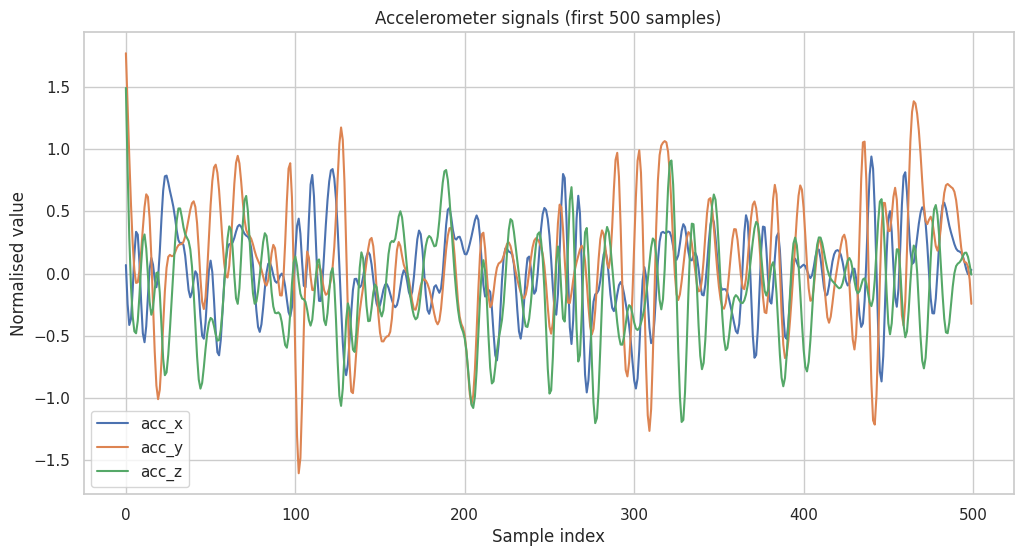

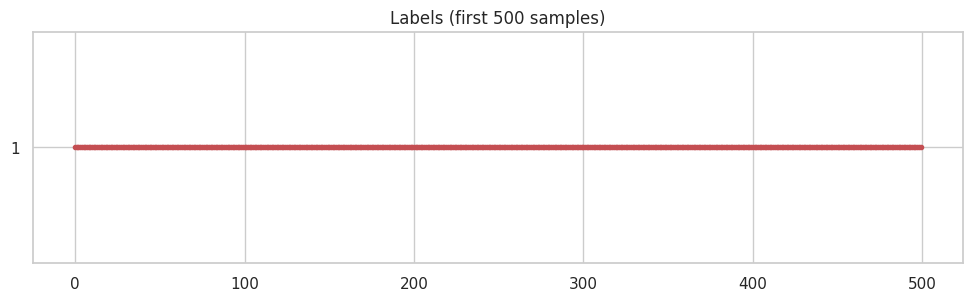

In [ ]:
# =========================================
# Extra: Visual sanity check of signals
# =========================================
sample = data.head(500)

plt.figure(figsize=(12,6))
plt.plot(sample['acc_x'], label='acc_x')
plt.plot(sample['acc_y'], label='acc_y')
plt.plot(sample['acc_z'], label='acc_z')
plt.title("Accelerometer signals (first 500 samples)")
plt.xlabel("Sample index")
plt.ylabel("Normalised value")
plt.legend()
plt.show()

if 'label' in sample.columns:
    plt.figure(figsize=(12,3))
    plt.plot(sample['label'].astype(str).values, 'r.')
    plt.title("Labels (first 500 samples)")
    plt.show()


In [ ]:
# =========================================
# 4. Feature Extraction (windowing)
# =========================================
def extract_features(df, window_size=100, overlap=0.5):
    features, labels = [], []
    step = int(window_size * (1 - overlap))
    for start in range(0, len(df) - window_size, step):
        end = start + window_size
        window = df.iloc[start:end]
        if 'label' not in window.columns:
            continue
        label = window['label'].mode()[0]
        feat = []
        for col in expected_cols:
            signal_data = window[col].values
            feat.append(np.mean(signal_data))
            feat.append(np.std(signal_data))
            feat.append(np.max(signal_data))
            feat.append(np.min(signal_data))
            feat.append(np.sqrt(np.mean(signal_data**2)))  # RMS
            freqs = np.fft.rfftfreq(len(signal_data), 1/fs)
            fft_magnitude = np.abs(np.fft.rfft(signal_data))
            dom_freq = freqs[np.argmax(fft_magnitude)]
            feat.append(dom_freq)
        features.append(feat)
        labels.append(label)
    return np.array(features), np.array(labels)

X, y = extract_features(data, window_size=128, overlap=0.5)
print("Feature shape:", X.shape, "Label shape:", y.shape)


Feature shape: (3344, 36) Label shape: (3344,)


In [ ]:
# =========================================
# 5. Train/Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
# =========================================
# 6. Model Training
# =========================================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)

models = {'Decision Tree': dt, 'Random Forest': rf, 'SVM': svm}



Decision Tree Results:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       206
           1       0.99      0.99      0.99       798

    accuracy                           0.98      1004
   macro avg       0.97      0.98      0.97      1004
weighted avg       0.98      0.98      0.98      1004



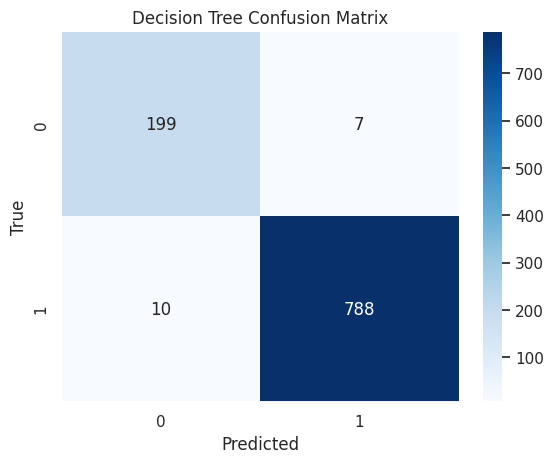


Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       206
           1       0.99      1.00      1.00       798

    accuracy                           1.00      1004
   macro avg       1.00      0.99      0.99      1004
weighted avg       1.00      1.00      0.99      1004



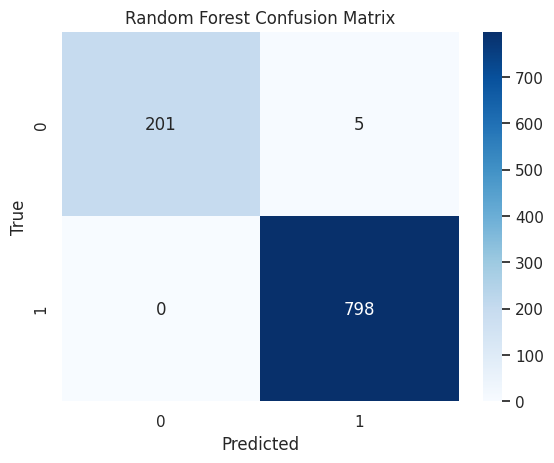


SVM Results:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       206
           1       0.99      0.99      0.99       798

    accuracy                           0.99      1004
   macro avg       0.98      0.98      0.98      1004
weighted avg       0.99      0.99      0.99      1004



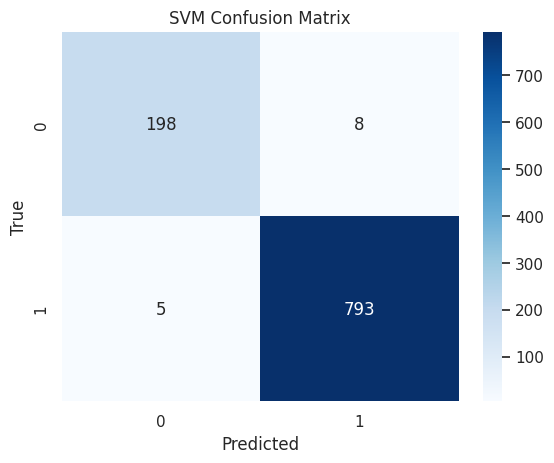

In [ ]:
# =========================================
# 7. Evaluation
# =========================================
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y),
                yticklabels=np.unique(y))
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [ ]:
# =========================================
# Extra: Cross-validation
# =========================================
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1_macro')
    print(f"{name} - CV mean F1: {scores.mean():.3f} (+/- {scores.std():.3f})")


Decision Tree - CV mean F1: 0.979 (+/- 0.012)
Random Forest - CV mean F1: 0.986 (+/- 0.019)
SVM - CV mean F1: 0.979 (+/- 0.028)


In [ ]:
# =========================================
# Extra: Window size comparison
# =========================================
for win in [64, 128, 256]:
    X_tmp, y_tmp = extract_features(data, window_size=win, overlap=0.5)
    X_train, X_test, y_train, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.3, random_state=42, stratify=y_tmp
    )
    rf_tmp = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_tmp.fit(X_train, y_train)
    y_pred = rf_tmp.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"Window {win} → Test F1: {f1:.3f}")


Window 64 → Test F1: 0.992
Window 128 → Test F1: 0.992
Window 256 → Test F1: 0.984


In [ ]:
# =========================================
# 9. Save Best Model
# =========================================
best_model = rf
joblib.dump(best_model, "/content/drive/MyDrive/datasets/pothole_detector2.pkl")
print("Model saved to Drive as pothole_detector.pkl")


Model saved to Drive as pothole_detector.pkl


In [ ]:
# =========================================
# Load UCI HAR Dataset
# =========================================
import os
import zipfile
import requests

# Download and unzip UCI HAR dataset if not already present
uci_folder = "/content/UCI_HAR_Dataset"
uci_zip = "/content/UCI_HAR_Dataset.zip"

if not os.path.exists(uci_folder):
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
    print("Downloading UCI HAR dataset...")
    r = requests.get(url)
    with open(uci_zip, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(uci_zip, "r") as zip_ref:
        zip_ref.extractall("/content/")
    os.rename("/content/UCI HAR Dataset", uci_folder)
    print("✅ UCI HAR dataset downloaded and extracted")

# Load train and test sets
X_train = pd.read_csv(os.path.join(uci_folder, "train", "X_train.txt"),
                      delim_whitespace=True, header=None)
y_train = pd.read_csv(os.path.join(uci_folder, "train", "y_train.txt"),
                      delim_whitespace=True, header=None)

X_test = pd.read_csv(os.path.join(uci_folder, "test", "X_test.txt"),
                     delim_whitespace=True, header=None)
y_test = pd.read_csv(os.path.join(uci_folder, "test", "y_test.txt"),
                     delim_whitespace=True, header=None)

# Combine
X_uci = pd.concat([X_train, X_test], axis=0)
y_uci = pd.concat([y_train, y_test], axis=0)

# Extract first 6 columns = body acc + gyro signals
X_uci = X_uci.iloc[:, 0:6]
X_uci.columns = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

# Add labels
data_uci = X_uci.copy()
data_uci["label"] = y_uci.values.flatten()

print("✅ UCI HAR dataset prepared")
print("Shape:", data_uci.shape)
print(data_uci.head())
print("\nClass distribution:")
print(data_uci['label'].value_counts())


✅ UCI HAR dataset downloaded and extracted


/tmp/ipython-input-1768170842.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(os.path.join(uci_folder, "train", "X_train.txt"),
/tmp/ipython-input-1768170842.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train = pd.read_csv(os.path.join(uci_folder, "train", "y_train.txt"),
/tmp/ipython-input-1768170842.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(os.path.join(uci_folder, "test", "X_test.txt"),


✅ UCI HAR dataset prepared
Shape: (10299, 7)
      acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z  label
0  0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526      5
1  0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322      5
2  0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944      5
3  0.279174 -0.026201 -0.123283 -0.996091 -0.983403 -0.990675      5
4  0.276629 -0.016570 -0.115362 -0.998139 -0.980817 -0.990482      5

Class distribution:
label
6    1944
5    1906
4    1777
1    1722
2    1544
3    1406
Name: count, dtype: int64


/tmp/ipython-input-1768170842.py:31: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_test = pd.read_csv(os.path.join(uci_folder, "test", "y_test.txt"),


In [ ]:
X, y = extract_features(data_uci, window_size=128, overlap=0.5)



🚀 Running pipeline on Pothole dataset (window=128)
Features: (3344, 36) Labels: (3344,)

===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       206
           1       0.99      0.99      0.99       798

    accuracy                           0.98      1004
   macro avg       0.97      0.98      0.97      1004
weighted avg       0.98      0.98      0.98      1004



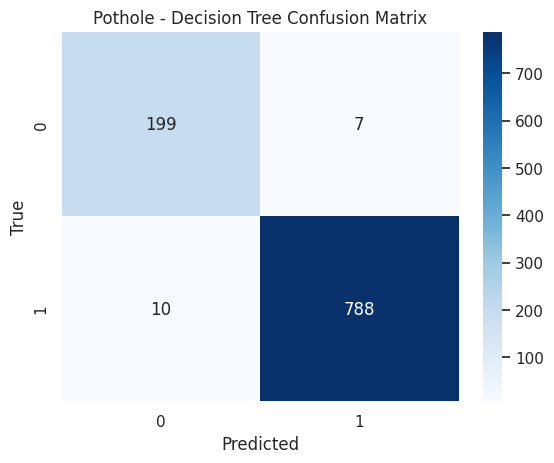

Cross-validation mean F1: 0.979 ± 0.012

===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       206
           1       0.99      1.00      1.00       798

    accuracy                           1.00      1004
   macro avg       1.00      0.99      0.99      1004
weighted avg       1.00      1.00      0.99      1004



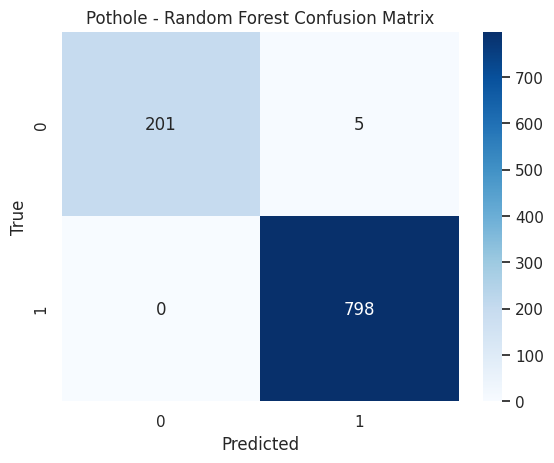

Cross-validation mean F1: 0.986 ± 0.019

===== SVM (RBF) =====
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       206
           1       0.99      0.99      0.99       798

    accuracy                           0.99      1004
   macro avg       0.98      0.98      0.98      1004
weighted avg       0.99      0.99      0.99      1004



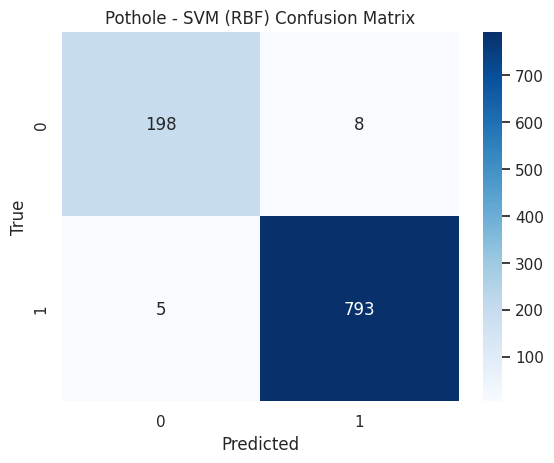

Cross-validation mean F1: 0.979 ± 0.028

🚀 Running pipeline on UCI HAR dataset (window=128)
Features: (159, 36) Labels: (159,)

===== Decision Tree =====
              precision    recall  f1-score   support

           1       0.36      0.45      0.40        11
           2       0.33      0.33      0.33         3
           4       0.17      0.20      0.18         5
           5       0.50      0.21      0.30        14
           6       0.21      0.27      0.24        15

    accuracy                           0.29        48
   macro avg       0.31      0.29      0.29        48
weighted avg       0.33      0.29      0.29        48



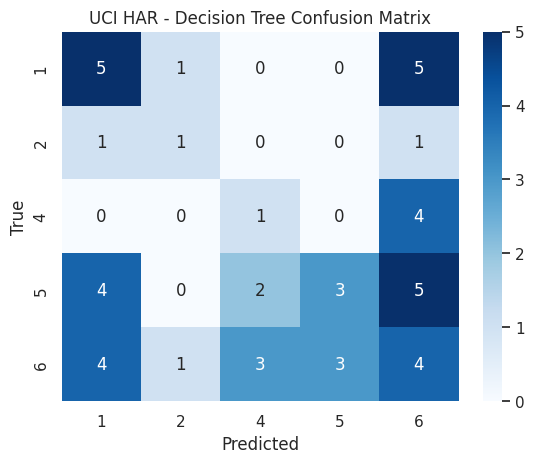

Cross-validation mean F1: 0.223 ± 0.067

===== Random Forest =====


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.29      0.45      0.36        11
           2       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         5
           5       0.30      0.21      0.25        14
           6       0.35      0.47      0.40        15

    accuracy                           0.31        48
   macro avg       0.19      0.23      0.20        48
weighted avg       0.26      0.31      0.28        48



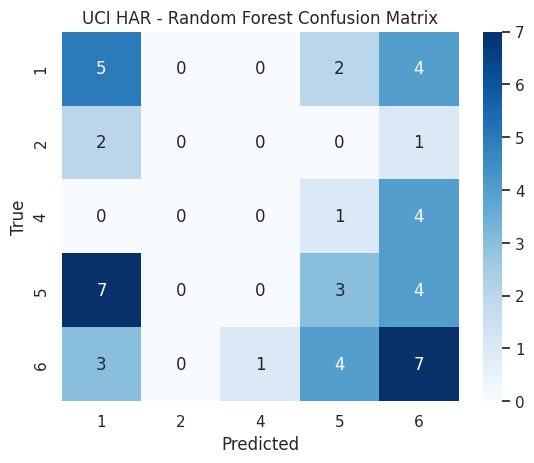

Cross-validation mean F1: 0.258 ± 0.079

===== SVM (RBF) =====
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         5
           5       0.00      0.00      0.00        14
           6       0.32      1.00      0.48        15

    accuracy                           0.31        48
   macro avg       0.06      0.20      0.10        48
weighted avg       0.10      0.31      0.15        48



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


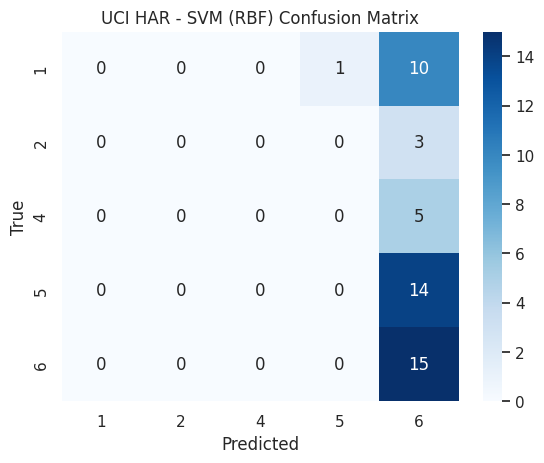

Cross-validation mean F1: 0.110 ± 0.021


In [ ]:
# =========================================
# Train, Evaluate & Cross-Validate
# =========================================

def run_pipeline(dataset_name, df, window_size=128, overlap=0.5):
    print(f"\n🚀 Running pipeline on {dataset_name} dataset (window={window_size})")

    # Feature extraction
    X, y = extract_features(df, window_size=window_size, overlap=overlap)
    print("Features:", X.shape, "Labels:", y.shape)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Models
    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    }

    # Train and evaluate
    for name, model in models.items():
        print(f"\n===== {name} =====")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluation
        print(classification_report(y_test, y_pred))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=np.unique(y), yticklabels=np.unique(y))
        plt.title(f"{dataset_name} - {name} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        # Cross-validation
        scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")
        print(f"Cross-validation mean F1: {scores.mean():.3f} ± {scores.std():.3f}")

# =========================================
# Run on pothole dataset
# =========================================
run_pipeline("Pothole", data, window_size=128, overlap=0.5)

# =========================================
# Run on UCI HAR dataset (optional)
# =========================================
run_pipeline("UCI HAR", data_uci, window_size=128, overlap=0.5)



🚀 Running pipeline on Pothole dataset (window=128)
Features: (3344, 36) Labels: (3344,)

===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       206
           1       0.99      0.99      0.99       798

    accuracy                           0.98      1004
   macro avg       0.97      0.98      0.97      1004
weighted avg       0.98      0.98      0.98      1004



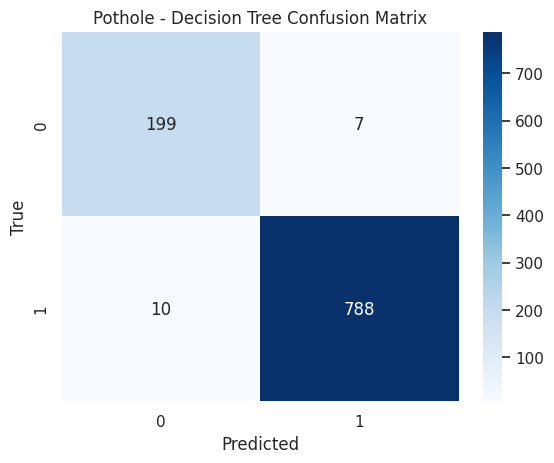

Cross-validation mean F1: 0.979 ± 0.012

===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       206
           1       0.99      1.00      1.00       798

    accuracy                           1.00      1004
   macro avg       1.00      0.99      0.99      1004
weighted avg       1.00      1.00      0.99      1004



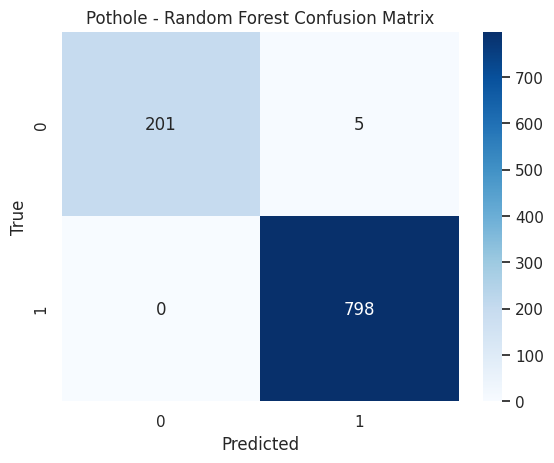

Cross-validation mean F1: 0.986 ± 0.019

===== SVM (RBF) =====
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       206
           1       0.99      0.99      0.99       798

    accuracy                           0.99      1004
   macro avg       0.98      0.98      0.98      1004
weighted avg       0.99      0.99      0.99      1004



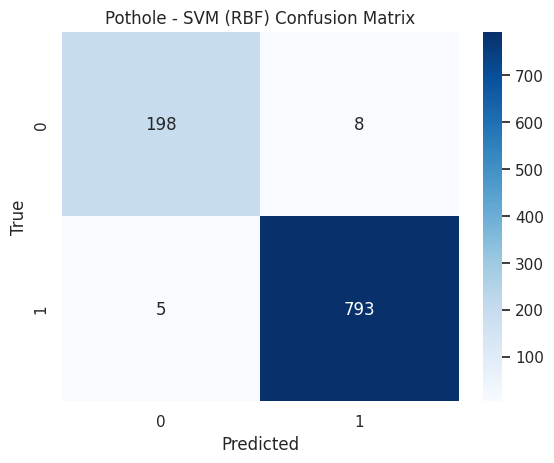

Cross-validation mean F1: 0.979 ± 0.028

🚀 Running pipeline on UCI HAR dataset (window=128)
Features: (159, 36) Labels: (159,)

===== Decision Tree =====
              precision    recall  f1-score   support

           1       0.36      0.45      0.40        11
           2       0.33      0.33      0.33         3
           4       0.17      0.20      0.18         5
           5       0.50      0.21      0.30        14
           6       0.21      0.27      0.24        15

    accuracy                           0.29        48
   macro avg       0.31      0.29      0.29        48
weighted avg       0.33      0.29      0.29        48



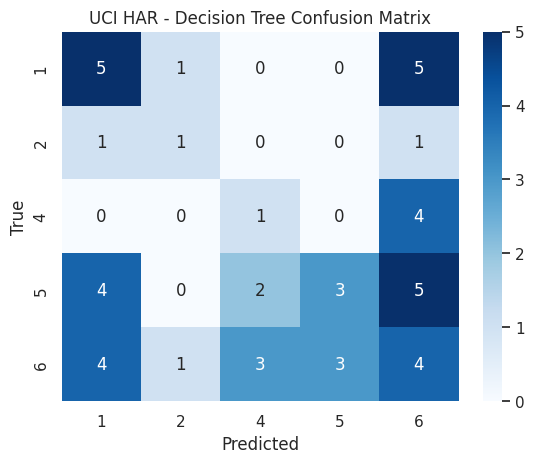

Cross-validation mean F1: 0.223 ± 0.067

===== Random Forest =====
              precision    recall  f1-score   support

           1       0.29      0.45      0.36        11
           2       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         5
           5       0.30      0.21      0.25        14
           6       0.35      0.47      0.40        15

    accuracy                           0.31        48
   macro avg       0.19      0.23      0.20        48
weighted avg       0.26      0.31      0.28        48



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


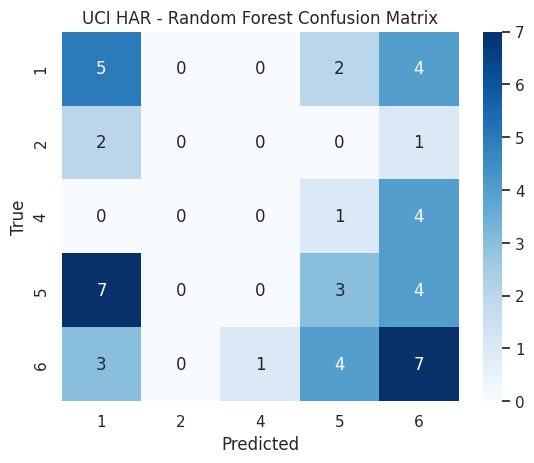

Cross-validation mean F1: 0.258 ± 0.079

===== SVM (RBF) =====
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         5
           5       0.00      0.00      0.00        14
           6       0.32      1.00      0.48        15

    accuracy                           0.31        48
   macro avg       0.06      0.20      0.10        48
weighted avg       0.10      0.31      0.15        48



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


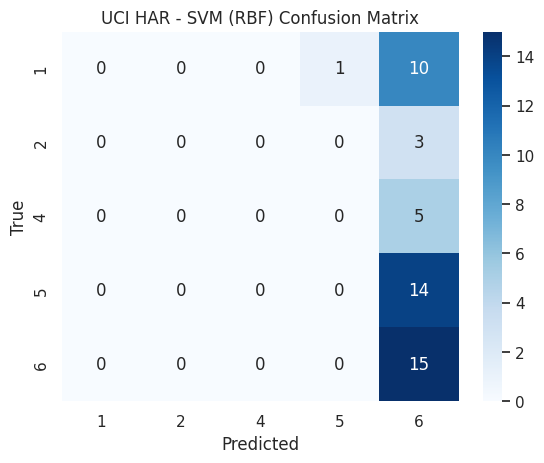

Cross-validation mean F1: 0.110 ± 0.021


,Dataset,Model,Test F1,CV Mean F1,CV Std F1
0,Pothole,Decision Tree,0.974182,0.978635,0.011831
1,Pothole,Random Forest,0.992296,0.986051,0.019304
2,Pothole,SVM (RBF),0.980043,0.979469,0.028069
3,UCI HAR,Decision Tree,0.290089,0.223351,0.066599
4,UCI HAR,Random Forest,0.201429,0.257839,0.079017
5,UCI HAR,SVM (RBF),0.096774,0.109650,0.020657


In [ ]:
# =========================================
# Train, Evaluate & Cross-Validate (Both Datasets)
# =========================================

def run_pipeline(dataset_name, df, window_size=128, overlap=0.5):
    print(f"\n🚀 Running pipeline on {dataset_name} dataset (window={window_size})")

    # Feature extraction
    X, y = extract_features(df, window_size=window_size, overlap=overlap)
    print("Features:", X.shape, "Labels:", y.shape)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Models
    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    }

    results = []

    # Train and evaluate
    for name, model in models.items():
        print(f"\n===== {name} =====")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluation
        print(classification_report(y_test, y_pred))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=np.unique(y), yticklabels=np.unique(y))
        plt.title(f"{dataset_name} - {name} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        # Cross-validation
        scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")
        mean_f1 = scores.mean()
        std_f1 = scores.std()
        print(f"Cross-validation mean F1: {mean_f1:.3f} ± {std_f1:.3f}")

        results.append({
            "Dataset": dataset_name,
            "Model": name,
            "Test F1": f1_score(y_test, y_pred, average="macro"),
            "CV Mean F1": mean_f1,
            "CV Std F1": std_f1
        })

    return pd.DataFrame(results)

# Run on pothole dataset
results_pothole = run_pipeline("Pothole", data, window_size=128, overlap=0.5)

# Run on UCI HAR dataset
results_uci = run_pipeline("UCI HAR", data_uci, window_size=128, overlap=0.5)

# Combine results
all_results = pd.concat([results_pothole, results_uci], ignore_index=True)
display(all_results)
